# Compare Real vs Generated DDM Params (v2.4.3)

这个 notebook 用于比较：

1. 真实数据中根据行为反推得到的 `v / a / t / z`
2. 生成数据中根据行为反推得到的 `v / a / t / z`
3. 生成模型在模拟数据中直接输出的“潜在参数” `v / a / t0 / z`

核心目标是判断：生成模型的参数趋势，能否与真实被试的趋势对上，从而评估模型对真实数据的拟合能力。

特别说明：

- 真实数据里的 `T / W` 使用的是秒，这里会统一转成毫秒 `ms`。
- `RT` 在参数估计时保留为秒 `s`，因为 EZ-diffusion 得到的 `t` 也是秒。
- 真实数据没有直接提供起点偏置 `z`，而且没有统一的上下边界编码，因此这里采用与生成模型一致的对称起点假设：`z = a / 2`。

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 220)

BASE_DIR = Path.cwd().parent.parent
REAL_PATH = BASE_DIR / '2_Data' / 'Real_Data' / 'EXP_data_combined.csv'
GEN_PATH = BASE_DIR / '2_Data' / 'Generate_Data' / 'Generate_Data_v2.4.3_checks' / 'gp_ddm_v2.4.3_large.csv'
FIG_DIR = BASE_DIR / '3_Figures' / 'Compare_Real_Generated_DDM_Params_v2.4.3'
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('真实数据路径:', REAL_PATH)
print('生成数据路径:', GEN_PATH)
print('图表输出目录:', FIG_DIR)

真实数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Real_Data\EXP_data_combined.csv
生成数据路径: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\2_Data\Generate_Data\Generate_Data_v2.4.3_checks\gp_ddm_v2.4.3_large.csv
图表输出目录: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.3


In [2]:
# 读取数据
real_raw = pd.read_csv(REAL_PATH)
gen_raw = pd.read_csv(GEN_PATH)

print('real_raw shape:', real_raw.shape)
print('gen_raw shape :', gen_raw.shape)
display(real_raw.head())
display(gen_raw.head())

real_raw shape: (26616, 18)
gen_raw shape : (120000, 19)


,groupID,subjectID,gender,age,handedness,stage,trialID,P,T,W,Shape,Label,CorrectKey,Response,RT,Correct,SourceFile,GroupInfo
0,1,1,1,23,2,formal,1,0,0.03,0.3,square,self,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
1,1,1,1,23,2,formal,2,0,0.03,0.3,square,stranger,f,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
2,1,1,1,23,2,formal,3,0,0.03,0.3,circle,self,f,f,0.23854,1,EXP_data_group1_1.csv,group1_1
3,1,1,1,23,2,formal,4,0,0.03,0.3,circle,stranger,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1
4,1,1,1,23,2,formal,5,0,0.03,0.3,square,self,j,NaN,NaN,0,EXP_data_group1_1.csv,group1_1


,subject,trial,P,T,W,M,label,v,a,t0,z,RT,response,v_s2,a_s2,v_gp_raw,a_gp_raw,v_mix,a_mix
0,1,1,142,480,1315,1795,stranger,-0.573219,3.363554,0.2,1.681777,1.164,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
1,1,2,142,480,1315,1795,stranger,1.241587,2.123674,0.2,1.061837,1.010,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
2,1,3,142,480,1315,1795,stranger,2.712455,2.699411,0.2,1.349705,0.468,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
3,1,4,142,480,1315,1795,stranger,0.337516,2.430360,0.2,1.215180,0.781,1,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338
4,1,5,142,480,1315,1795,stranger,1.515241,3.038043,0.2,1.519021,1.795,0,1.758841,3.599977,0.215835,1.126784,0.987338,2.36338


## 一、预处理与单位统一

In [3]:
# 真实数据预处理
real = real_raw.copy()
real = real[real['stage'].astype(str).str.lower() == 'formal'].copy() if 'stage' in real.columns else real.copy()

real = real.rename(columns={
    'subjectID': 'subject',
    'Label': 'label',
    'Correct': 'correct',
    'RT': 'rt_s',
})

# T / W 统一成毫秒；RT 保留秒
real['T_ms'] = real['T'] * 1000.0
real['W_ms'] = real['W'] * 1000.0
real['label'] = real['label'].astype(str).str.lower()
real['correct'] = pd.to_numeric(real['correct'], errors='coerce').fillna(0).astype(int)
real['rt_s'] = pd.to_numeric(real['rt_s'], errors='coerce')
real['dataset'] = 'real'

# 生成数据预处理
gen = gen_raw.copy()
gen['T_ms'] = pd.to_numeric(gen['T'], errors='coerce')
gen['W_ms'] = pd.to_numeric(gen['W'], errors='coerce')
gen['rt_s'] = pd.to_numeric(gen['RT'], errors='coerce')
gen['label'] = gen['label'].astype(str).str.lower()
gen['correct'] = (pd.to_numeric(gen['response'], errors='coerce') == 1).astype(int)
gen['dataset'] = 'generated'

print('真实数据 T(ms) unique:', sorted(real['T_ms'].dropna().unique().tolist()))
print('真实数据 W(ms) unique:', sorted(real['W_ms'].dropna().unique().tolist()))
print('生成数据 T(ms) range:', (gen['T_ms'].min(), gen['T_ms'].max()))
print('生成数据 W(ms) range:', (gen['W_ms'].min(), gen['W_ms'].max()))

真实数据 T(ms) unique: [30.0, 80.0, 100.0, 500.0]
真实数据 W(ms) unique: [300.0, 600.0, 1100.0, 1500.0]
生成数据 T(ms) range: (np.int64(10), np.int64(599))
生成数据 W(ms) range: (np.int64(200), np.int64(1499))


In [4]:
# 真实实验条件表
real_conditions = (
    real[['P', 'T_ms', 'W_ms']]
        .drop_duplicates()
        .sort_values(['P', 'T_ms', 'W_ms'])
        .reset_index(drop=True)
)
real_conditions['condition_id'] = [f'C{i+1}' for i in range(len(real_conditions))]
display(real_conditions)

cond_lookup = real_conditions.copy()

,P,T_ms,W_ms,condition_id
0,0,30.0,300.0,C1
1,0,30.0,600.0,C2
2,8,100.0,1100.0,C3
3,120,30.0,600.0,C4
4,120,80.0,600.0,C5
5,120,500.0,1500.0,C6


In [5]:
# 把真实数据直接挂上 condition_id
real = real.merge(cond_lookup, on=['P', 'T_ms', 'W_ms'], how='left')

# 生成数据由于是连续采样，需要映射到最近的真实实验条件
scale_P = max(cond_lookup['P'].max() - cond_lookup['P'].min(), 1)
scale_T = max(cond_lookup['T_ms'].max() - cond_lookup['T_ms'].min(), 1)
scale_W = max(cond_lookup['W_ms'].max() - cond_lookup['W_ms'].min(), 1)

gen_subject_conditions = gen[['subject', 'P', 'T_ms', 'W_ms']].drop_duplicates().copy()

def assign_nearest_condition(row, cond_df):
    distances = (
        ((cond_df['P'] - row['P']) / scale_P) ** 2
        + ((cond_df['T_ms'] - row['T_ms']) / scale_T) ** 2
        + ((cond_df['W_ms'] - row['W_ms']) / scale_W) ** 2
    )
    idx = distances.idxmin()
    return cond_df.loc[idx, ['condition_id', 'P', 'T_ms', 'W_ms']]

assigned = gen_subject_conditions.apply(lambda row: assign_nearest_condition(row, cond_lookup), axis=1)
assigned = pd.concat([gen_subject_conditions[['subject']].reset_index(drop=True), assigned.reset_index(drop=True)], axis=1)
assigned = assigned.rename(columns={'P': 'P_target', 'T_ms': 'T_ms_target', 'W_ms': 'W_ms_target'})

gen = gen.merge(assigned, on='subject', how='left')

print('生成数据分配到最近真实条件后的 subject 数量：')
display(assigned['condition_id'].value_counts().sort_index())

生成数据分配到最近真实条件后的 subject 数量：


condition_id
C1    141
C2     94
C3    504
C4     87
C5    564
C6    610
Name: count, dtype: int64

## 二、EZ-diffusion 参数估计

这里使用 EZ-diffusion 的近似公式，从行为数据估计：

- `v`：漂移率
- `a`：边界分离
- `t`：非决策时长

对于 `z`：由于真实数据没有统一的上下边界编码，无法稳定估计起点偏置，因此这里采用生成模型的一致设定：`z = a / 2`。

In [6]:
def ez_diffusion_from_group(df_group, rt_col='rt_s', correct_col='correct', s=0.1):
    n_total = len(df_group)
    if n_total < 4:
        return pd.Series({'pc': np.nan, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': 0, 'valid_ez': 0})

    pc_raw = df_group[correct_col].mean()
    pc = (df_group[correct_col].sum() + 0.5) / (n_total + 1.0)
    pc = float(np.clip(pc, 1e-4, 1 - 1e-4))

    correct_rt = df_group.loc[(df_group[correct_col] == 1) & df_group[rt_col].notna(), rt_col]
    n_correct_rt = len(correct_rt)
    if n_correct_rt < 3:
        return pd.Series({'pc': pc_raw, 'mrt': np.nan, 'vrt': np.nan, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    mrt = correct_rt.mean()
    vrt = correct_rt.var(ddof=1)
    if (pc <= 0.5) or (vrt <= 0) or np.isnan(vrt):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    logit_p = np.log(pc / (1 - pc))
    x = logit_p * (pc**2 * logit_p - pc * logit_p + pc - 0.5) / vrt
    if x <= 0 or np.isnan(x):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    v = s * np.power(x, 0.25)
    if v == 0 or np.isnan(v):
        return pd.Series({'pc': pc_raw, 'mrt': mrt, 'vrt': vrt, 'v_est': np.nan, 'a_est': np.nan, 't_est': np.nan, 'z_est': np.nan, 'n_total': n_total, 'n_correct_rt': n_correct_rt, 'valid_ez': 0})

    a = (s ** 2) * logit_p / v
    y = (-v * a) / (s ** 2)
    mdt = (a / (2 * v)) * ((1 - np.exp(y)) / (1 + np.exp(y)))
    ter = mrt - mdt
    z = a / 2.0

    if np.any(np.isnan([v, a, ter, z])):
        valid = 0
    else:
        valid = int((a > 0) and (ter >= 0))

    return pd.Series({
        'pc': pc_raw,
        'mrt': mrt,
        'vrt': vrt,
        'v_est': v if valid else np.nan,
        'a_est': a if valid else np.nan,
        't_est': ter if valid else np.nan,
        'z_est': z if valid else np.nan,
        'n_total': n_total,
        'n_correct_rt': n_correct_rt,
        'valid_ez': valid,
    })

In [7]:
def estimate_subject_level_params(df, dataset_name):
    if dataset_name == 'real':
        group_cols = ['subject', 'condition_id', 'P', 'T_ms', 'W_ms', 'label']
    else:
        group_cols = ['subject', 'condition_id', 'P_target', 'T_ms_target', 'W_ms_target', 'label']

    rows = []
    for keys, g in df.groupby(group_cols):
        if not isinstance(keys, tuple):
            keys = (keys,)
        row = dict(zip(group_cols, keys))
        row.update(ez_diffusion_from_group(g).to_dict())
        rows.append(row)

    out = pd.DataFrame(rows)
    out['dataset'] = dataset_name

    if dataset_name == 'generated':
        latent = (
            df.groupby(group_cols, as_index=False)
              .agg(
                  v_latent=('v', 'mean'),
                  a_latent=('a', 'mean'),
                  t_latent=('t0', 'mean'),
                  z_latent=('z', 'mean'),
              )
        )
        out = out.merge(latent, on=group_cols, how='left')
    return out

In [8]:
real_est = estimate_subject_level_params(real, 'real')
gen_est = estimate_subject_level_params(gen, 'generated')

print('真实数据 EZ 有效估计数:')
display(real_est['valid_ez'].value_counts(dropna=False))
print('生成数据 EZ 有效估计数:')
display(gen_est['valid_ez'].value_counts(dropna=False))

display(real_est.head())
display(gen_est.head())

真实数据 EZ 有效估计数:


valid_ez
0.0    60
1.0    32
Name: count, dtype: int64

生成数据 EZ 有效估计数:


valid_ez
1.0    3789
0.0     211
Name: count, dtype: int64

,subject,condition_id,P,T_ms,W_ms,label,pc,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_correct_rt,valid_ez,dataset
0,1,C1,0,30.0,300.0,self,0.100000,0.265002,0.001212,NaN,NaN,NaN,NaN,260.0,26.0,0.0,real
1,1,C1,0,30.0,300.0,stranger,0.088462,0.254494,0.000828,NaN,NaN,NaN,NaN,260.0,23.0,0.0,real
2,1,C2,0,30.0,600.0,self,0.303846,0.357276,0.013232,NaN,NaN,NaN,NaN,260.0,79.0,0.0,real
3,1,C2,0,30.0,600.0,stranger,0.296154,0.385955,0.016142,NaN,NaN,NaN,NaN,260.0,77.0,0.0,real
4,1,C3,8,100.0,1100.0,self,0.750000,0.635894,0.029942,0.112259,0.097409,0.419796,0.048705,260.0,195.0,1.0,real


,subject,condition_id,P_target,T_ms_target,W_ms_target,label,pc,mrt,vrt,v_est,a_est,t_est,z_est,n_total,n_correct_rt,valid_ez,dataset,v_latent,a_latent,t_latent,z_latent
0,1,C6,120,500.0,1500.0,self,1.000000,0.571433,0.047952,0.244761,0.167955,0.239401,0.083977,30.0,30.0,1.0,generated,3.749712,2.368134,0.2,1.184067
1,1,C6,120,500.0,1500.0,stranger,0.766667,0.872000,0.147735,0.078292,0.145877,0.391160,0.072939,30.0,23.0,1.0,generated,1.191880,2.543808,0.2,1.271904
2,2,C6,120,500.0,1500.0,self,1.000000,0.543733,0.036608,0.261848,0.156995,0.253621,0.078497,30.0,30.0,1.0,generated,3.667813,2.224799,0.2,1.112399
3,2,C6,120,500.0,1500.0,stranger,0.666667,0.884200,0.108834,0.051489,0.129941,0.477156,0.064970,30.0,20.0,1.0,generated,0.863132,2.463563,0.2,1.231782
4,3,C5,120,80.0,600.0,self,0.933333,0.618643,0.086604,0.160969,0.151185,0.224778,0.075593,30.0,28.0,1.0,generated,2.319554,1.656534,0.2,0.828267


## 三、条件层面的汇总对比

In [9]:
real_cond = (
    real_est[real_est['valid_ez'] == 1]
    .groupby(['condition_id', 'label'], as_index=False)
    .agg(
        P=('P', 'mean'),
        T_ms=('T_ms', 'mean'),
        W_ms=('W_ms', 'mean'),
        v_real=('v_est', 'mean'),
        a_real=('a_est', 'mean'),
        t_real=('t_est', 'mean'),
        z_real=('z_est', 'mean'),
        pc_real=('pc', 'mean'),
        n_real=('subject', 'nunique'),
    )
)

gen_cond = (
    gen_est[gen_est['valid_ez'] == 1]
    .groupby(['condition_id', 'label'], as_index=False)
    .agg(
        P=('P_target', 'mean'),
        T_ms=('T_ms_target', 'mean'),
        W_ms=('W_ms_target', 'mean'),
        v_gen_est=('v_est', 'mean'),
        a_gen_est=('a_est', 'mean'),
        t_gen_est=('t_est', 'mean'),
        z_gen_est=('z_est', 'mean'),
        pc_gen_est=('pc', 'mean'),
        n_gen=('subject', 'nunique'),
    )
)

gen_latent_cond = (
    gen_est.groupby(['condition_id', 'label'], as_index=False)
    .agg(
        v_gen_latent=('v_latent', 'mean'),
        a_gen_latent=('a_latent', 'mean'),
        t_gen_latent=('t_latent', 'mean'),
        z_gen_latent=('z_latent', 'mean'),
    )
)

compare_cond = (
    real_cond
      .merge(gen_cond, on=['condition_id', 'label', 'P', 'T_ms', 'W_ms'], how='outer')
      .merge(gen_latent_cond, on=['condition_id', 'label'], how='outer')
      .sort_values(['condition_id', 'label'])
      .reset_index(drop=True)
)

compare_cond['condition_text'] = compare_cond.apply(lambda r: f"{r['condition_id']} | P={int(r['P'])}, T={int(r['T_ms'])}, W={int(r['W_ms'])}", axis=1)
display(compare_cond)

,condition_id,label,P,T_ms,W_ms,v_real,a_real,t_real,z_real,pc_real,n_real,v_gen_est,a_gen_est,t_gen_est,z_gen_est,pc_gen_est,n_gen,v_gen_latent,a_gen_latent,t_gen_latent,z_gen_latent,condition_text
0,C1,self,0.0,30.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,0.173954,0.136845,0.173653,0.068423,0.887290,139,2.489209,1.493657,0.2,0.746828,"C1 | P=0, T=30, W=300"
1,C1,stranger,0.0,30.0,300.0,NaN,NaN,NaN,NaN,NaN,NaN,0.054185,0.135188,0.214622,0.067594,0.676694,123,0.693115,1.490983,0.2,0.745492,"C1 | P=0, T=30, W=300"
2,C2,self,0.0,30.0,600.0,0.092405,0.055945,0.435881,0.027973,0.626923,1.0,0.127651,0.155031,0.212612,0.077516,0.859783,92,1.896059,1.926330,0.2,0.963165,"C2 | P=0, T=30, W=600"
3,C2,stranger,0.0,30.0,600.0,0.030723,0.055002,0.443721,0.027501,0.542308,1.0,0.040826,0.146359,0.271536,0.073180,0.645778,75,0.549860,1.900326,0.2,0.950163,"C2 | P=0, T=30, W=600"
4,C3,self,8.0,100.0,1100.0,0.152045,0.099003,0.499929,0.049502,0.803297,7.0,0.155535,0.166875,0.254592,0.083437,0.912867,500,2.307086,2.354363,0.2,1.177182,"C3 | P=8, T=100, W=1100"
5,C3,stranger,8.0,100.0,1100.0,0.097129,0.094797,0.538902,0.047398,0.705495,7.0,0.038919,0.152154,0.372710,0.076077,0.645024,422,0.643667,2.348519,0.2,1.174260,"C3 | P=8, T=100, W=1100"
6,C4,self,120.0,30.0,600.0,NaN,NaN,NaN,NaN,NaN,NaN,0.089067,0.143991,0.255830,0.071995,0.777778,87,1.345622,1.900951,0.2,0.950475,"C4 | P=120, T=30, W=600"
7,C4,stranger,120.0,30.0,600.0,NaN,NaN,NaN,NaN,NaN,NaN,0.033285,0.135949,0.315121,0.067975,0.610909,55,0.423425,1.897556,0.2,0.948778,"C4 | P=120, T=30, W=600"
8,C5,self,120.0,80.0,600.0,0.085864,0.069376,0.405497,0.034688,0.622115,4.0,0.196379,0.157673,0.205151,0.078836,0.947898,563,2.856819,2.021511,0.2,1.010755,"C5 | P=120, T=80, W=600"
9,C5,stranger,120.0,80.0,600.0,0.125779,0.067779,0.406303,0.033889,0.669231,2.0,0.048923,0.144864,0.312564,0.072432,0.669587,525,0.772758,2.026632,0.2,1.013316,"C5 | P=120, T=80, W=600"


In [10]:
def compute_alignment(df, real_col, other_col):
    temp = df[[real_col, other_col]].dropna()
    if len(temp) < 3:
        return np.nan
    return temp[real_col].corr(temp[other_col], method='spearman')

rows = []
for label in sorted(compare_cond['label'].dropna().unique()):
    sub = compare_cond[compare_cond['label'] == label]
    for param, real_col, gen_est_col, gen_latent_col in [
        ('v', 'v_real', 'v_gen_est', 'v_gen_latent'),
        ('a', 'a_real', 'a_gen_est', 'a_gen_latent'),
        ('t', 't_real', 't_gen_est', 't_gen_latent'),
        ('z', 'z_real', 'z_gen_est', 'z_gen_latent'),
    ]:
        rows.append({
            'label': label,
            'param': param,
            'spearman_real_vs_gen_est': compute_alignment(sub, real_col, gen_est_col),
            'spearman_real_vs_gen_latent': compute_alignment(sub, real_col, gen_latent_col),
        })

alignment_df = pd.DataFrame(rows)
display(alignment_df)

c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]
c:\Users\蔡振辛\AppData\Local\Programs\Python\Python313\Lib\site-packages\pandas\core\nanops.py:1632: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  return spearmanr(a, b)[0]


,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent
0,self,v,0.4,0.4
1,self,a,0.8,1.0
2,self,t,0.8,NaN
3,self,z,0.8,1.0
4,stranger,v,0.8,1.0
5,stranger,a,0.8,1.0
6,stranger,t,0.6,NaN
7,stranger,z,0.8,1.0


## 四、趋势图：真实估计 vs 生成估计 vs 生成潜在参数

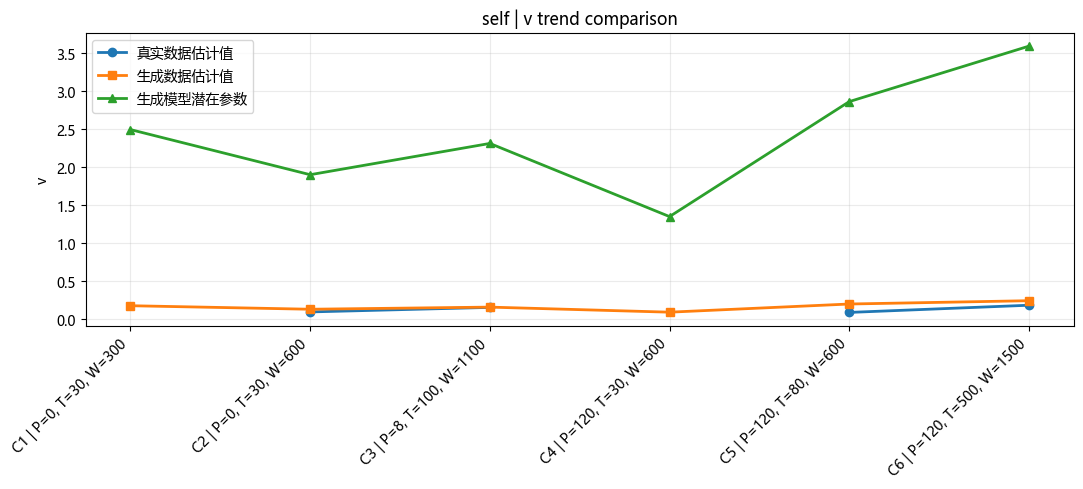

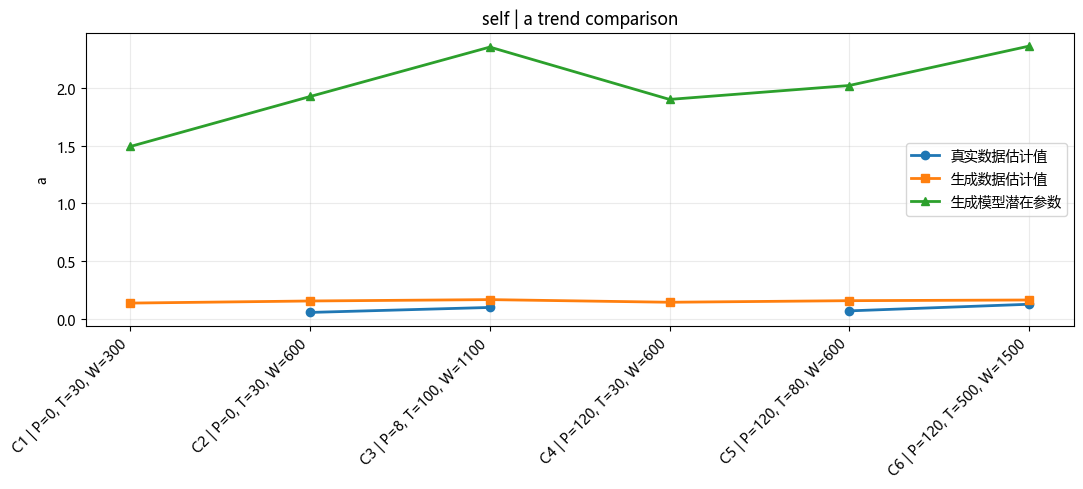

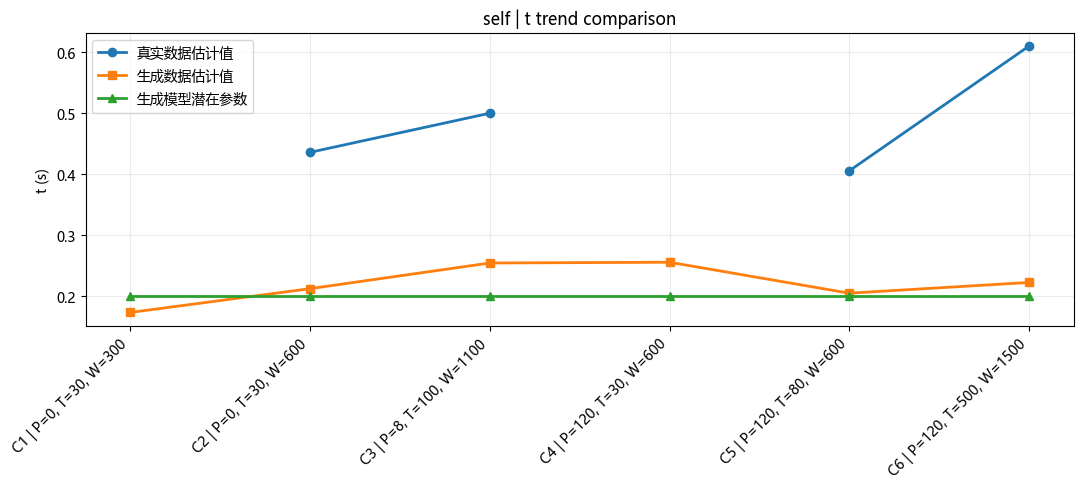

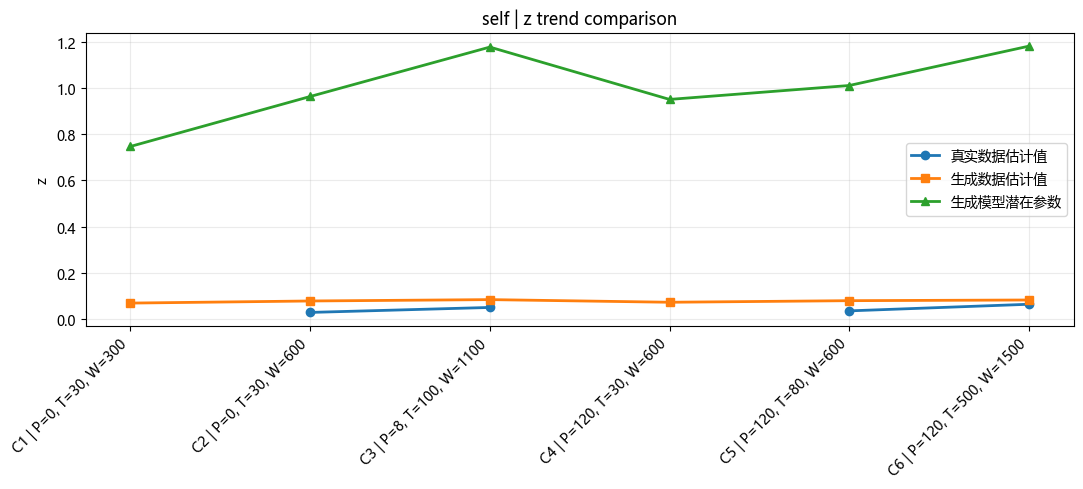

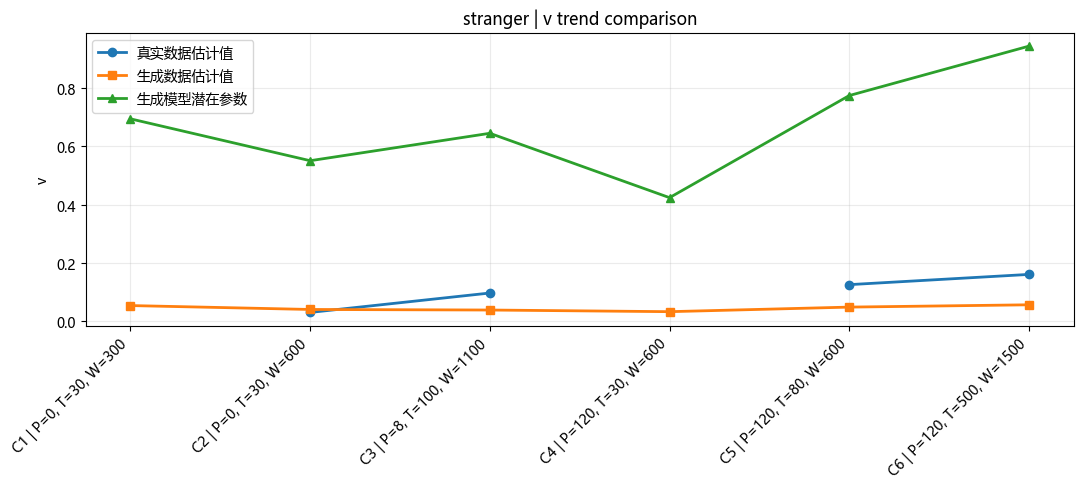

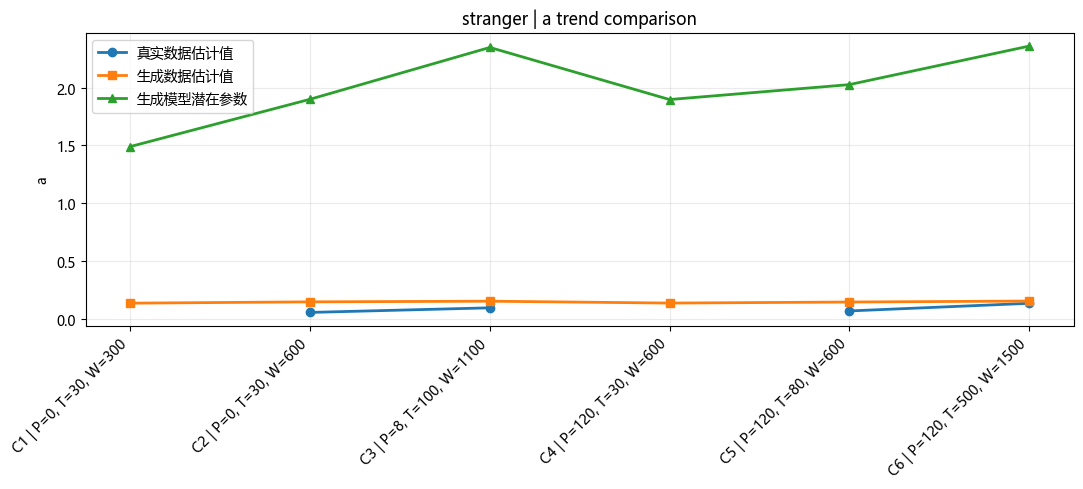

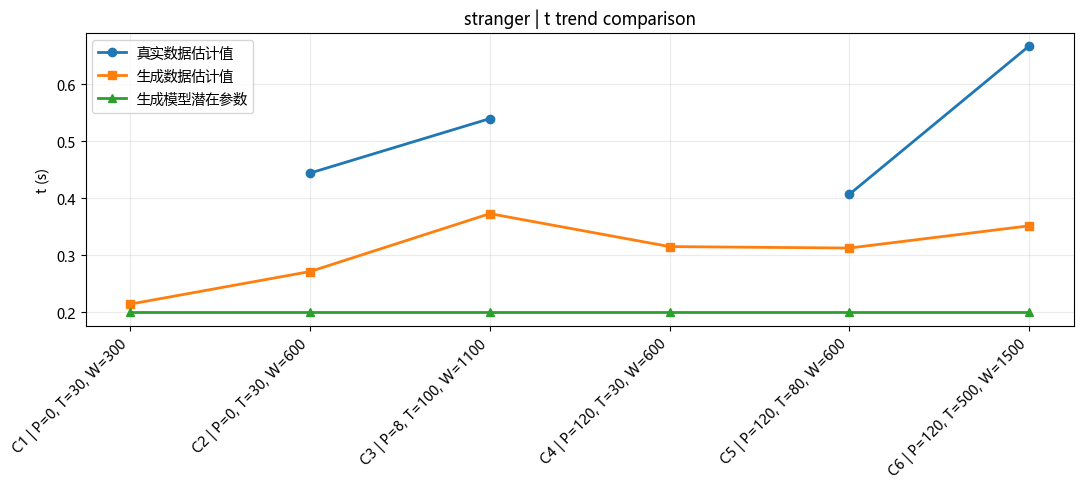

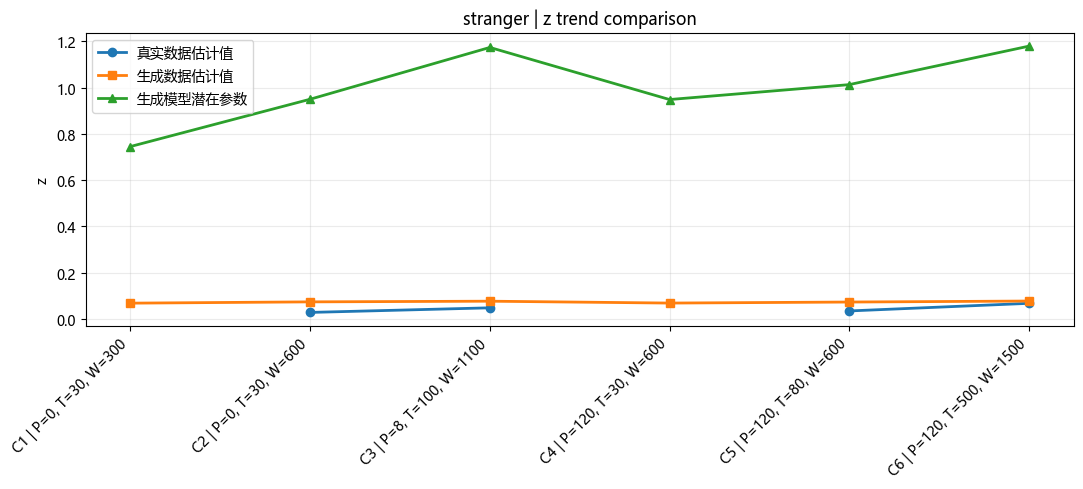

In [11]:
def plot_param_trends(compare_df, label_value, param_name, save_name=None):
    param_map = {
        'v': ('v_real', 'v_gen_est', 'v_gen_latent', 'v'),
        'a': ('a_real', 'a_gen_est', 'a_gen_latent', 'a'),
        't': ('t_real', 't_gen_est', 't_gen_latent', 't (s)'),
        'z': ('z_real', 'z_gen_est', 'z_gen_latent', 'z'),
    }
    real_col, gen_est_col, gen_latent_col, ylab = param_map[param_name]
    sub = compare_df[compare_df['label'] == label_value].sort_values(['P', 'T_ms', 'W_ms'])
    x = np.arange(len(sub))

    plt.figure(figsize=(11, 5))
    plt.plot(x, sub[real_col], marker='o', linewidth=2, label='真实数据估计值')
    plt.plot(x, sub[gen_est_col], marker='s', linewidth=2, label='生成数据估计值')
    plt.plot(x, sub[gen_latent_col], marker='^', linewidth=2, label='生成模型潜在参数')
    plt.xticks(x, sub['condition_text'], rotation=45, ha='right')
    plt.ylabel(ylab)
    plt.title(f'{label_value} | {param_name} trend comparison')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_cond['label'].dropna().unique()):
    for param in ['v', 'a', 't', 'z']:
        plot_param_trends(compare_cond, label, param, save_name=f'{label}_{param}_trend_compare.png')

## 五、按 P / T / W 看参数趋势

下面这部分把条件层面的结果再压缩成 `P / T / W` 三个维度的边际趋势图，用来看大方向是否一致。

注意：真实数据不是完全正交设计，因此这些图主要用于看总体趋势，不应替代正式的交互建模。

In [12]:
long_rows = []
for _, row in compare_cond.iterrows():
    for source_name, prefix in [('真实数据估计值', 'real'), ('生成数据估计值', 'gen_est'), ('生成模型潜在参数', 'gen_latent')]:
        long_rows.append({
            'condition_id': row['condition_id'],
            'label': row['label'],
            'P': row['P'],
            'T_ms': row['T_ms'],
            'W_ms': row['W_ms'],
            'source': source_name,
            'v': row.get('v_real' if prefix == 'real' else ('v_gen_est' if prefix == 'gen_est' else 'v_gen_latent'), np.nan),
            'a': row.get('a_real' if prefix == 'real' else ('a_gen_est' if prefix == 'gen_est' else 'a_gen_latent'), np.nan),
            't': row.get('t_real' if prefix == 'real' else ('t_gen_est' if prefix == 'gen_est' else 't_gen_latent'), np.nan),
            'z': row.get('z_real' if prefix == 'real' else ('z_gen_est' if prefix == 'gen_est' else 'z_gen_latent'), np.nan),
        })

compare_long = pd.DataFrame(long_rows)
display(compare_long.head())

,condition_id,label,P,T_ms,W_ms,source,v,a,t,z
0,C1,self,0.0,30.0,300.0,真实数据估计值,NaN,NaN,NaN,NaN
1,C1,self,0.0,30.0,300.0,生成数据估计值,0.173954,0.136845,0.173653,0.068423
2,C1,self,0.0,30.0,300.0,生成模型潜在参数,2.489209,1.493657,0.200000,0.746828
3,C1,stranger,0.0,30.0,300.0,真实数据估计值,NaN,NaN,NaN,NaN
4,C1,stranger,0.0,30.0,300.0,生成数据估计值,0.054185,0.135188,0.214622,0.067594


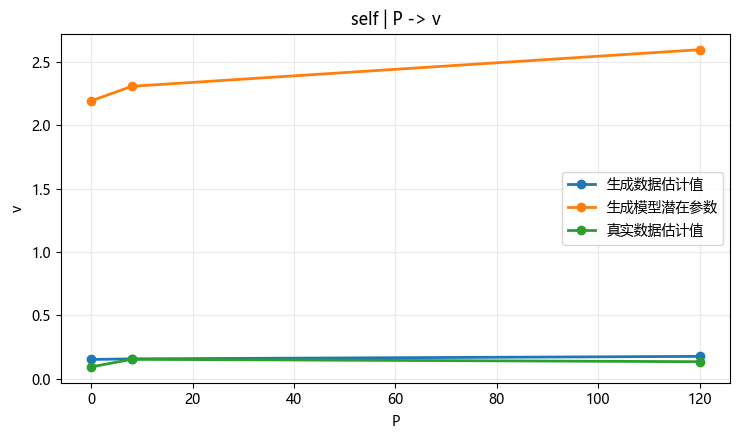

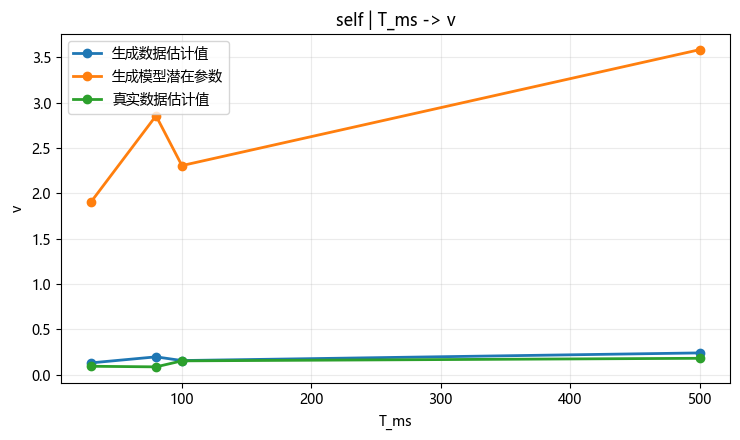

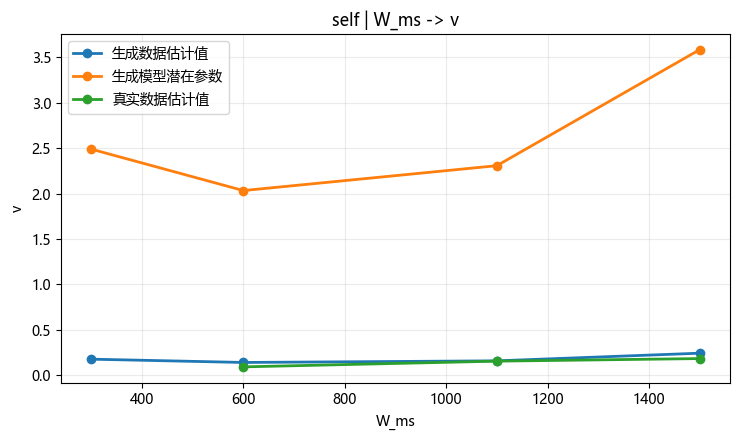

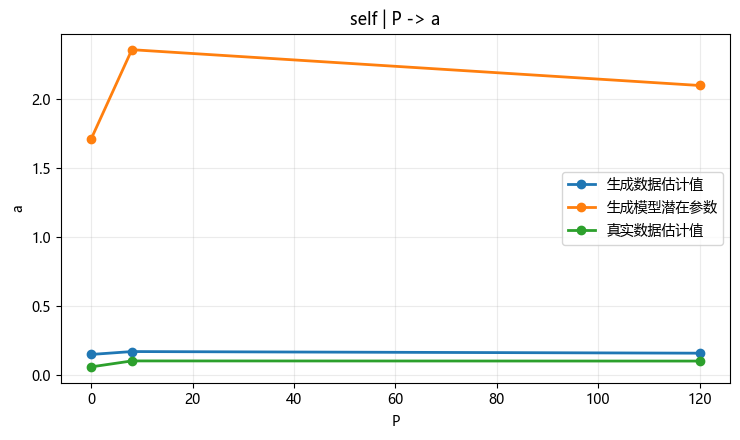

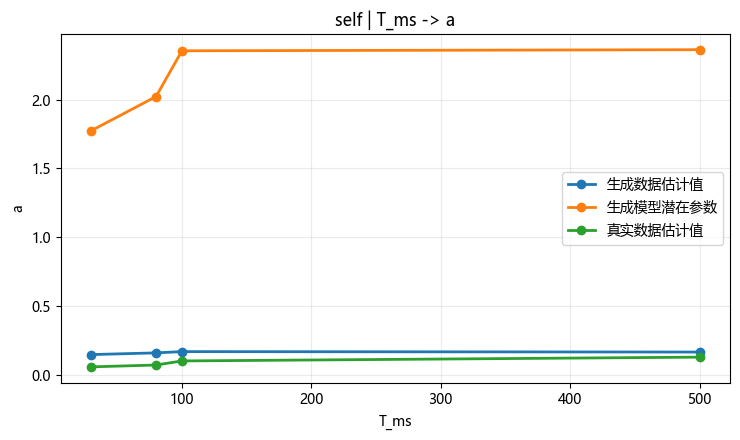

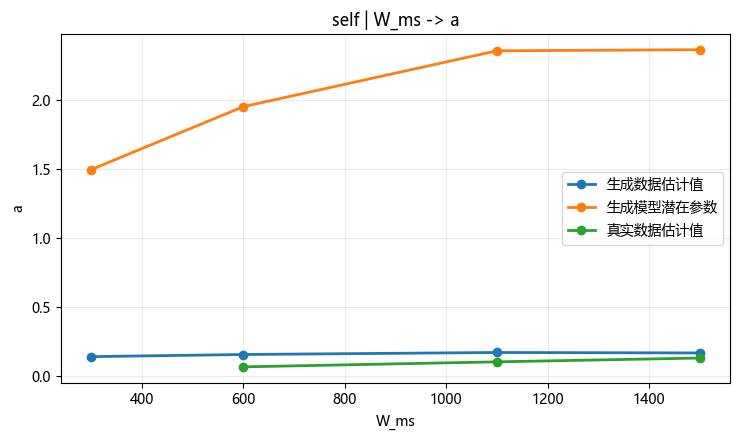

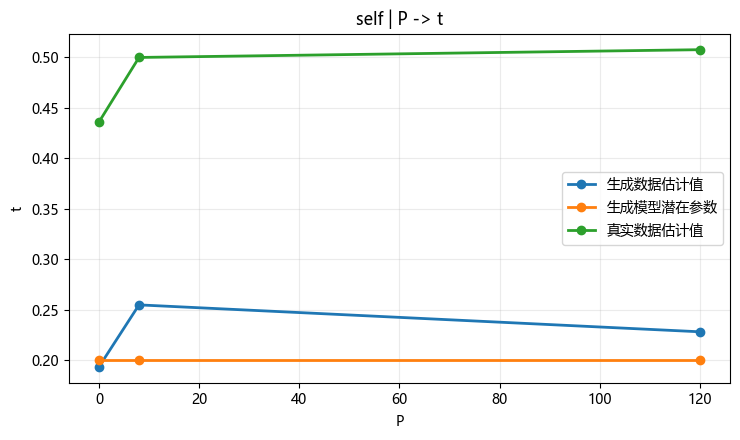

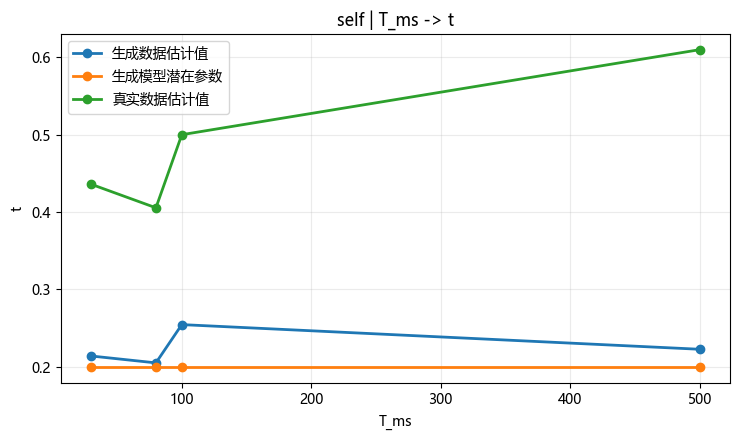

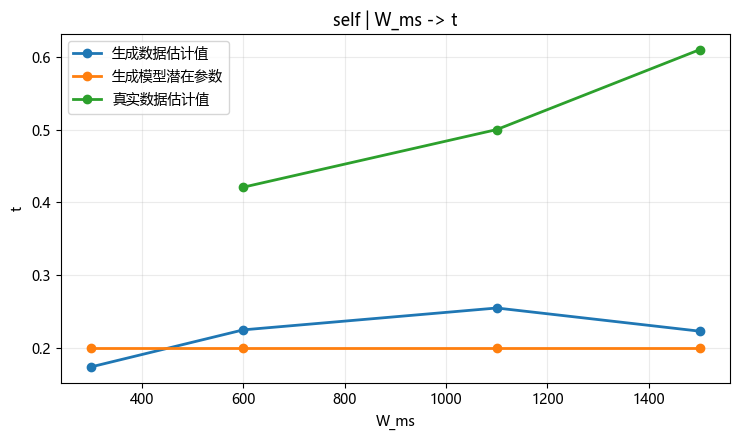

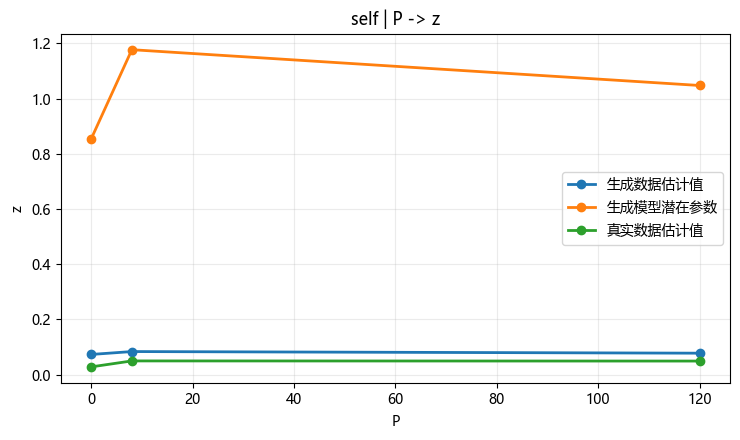

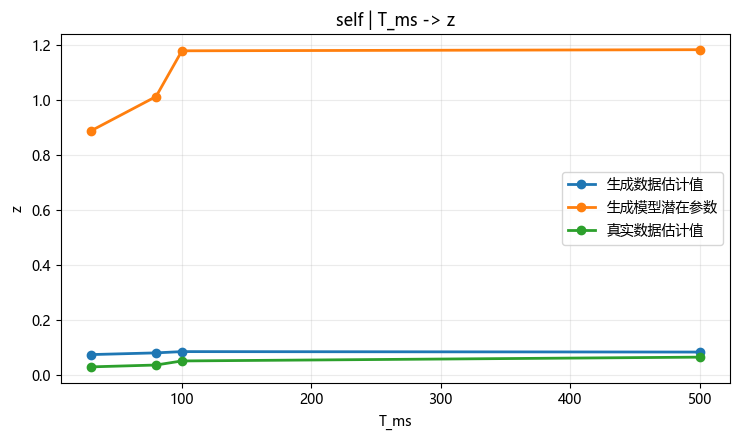

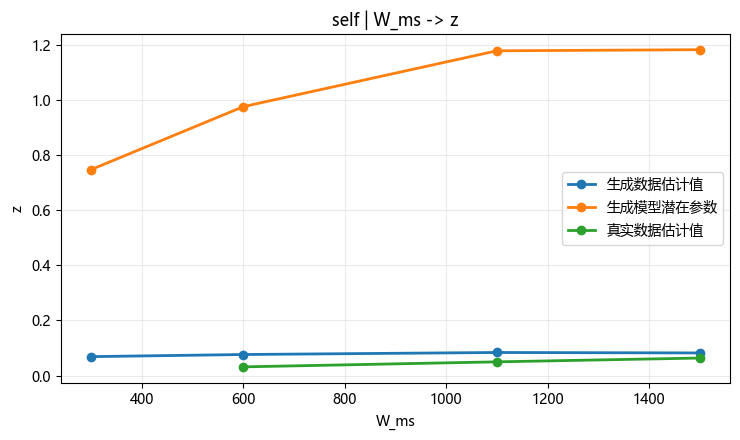

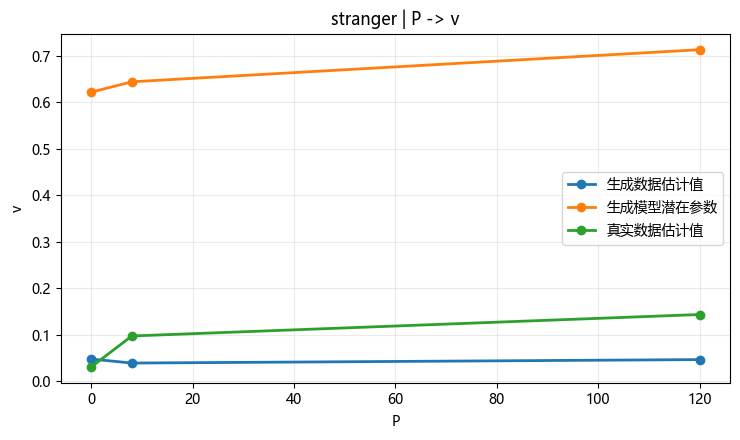

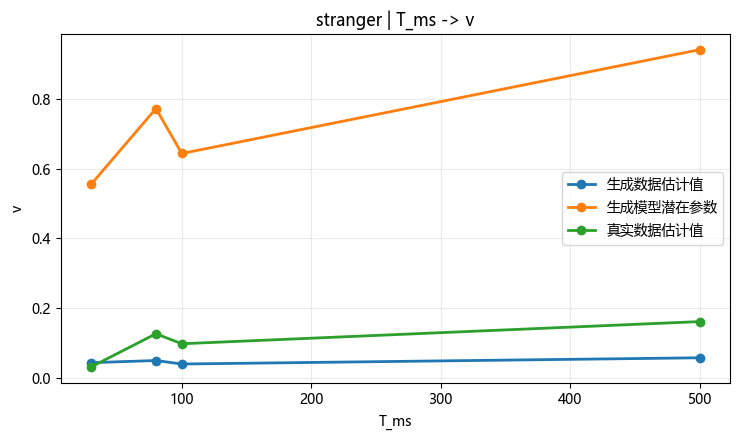

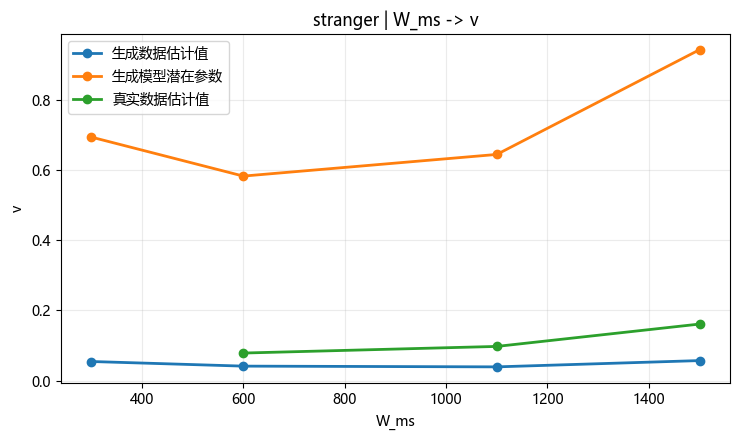

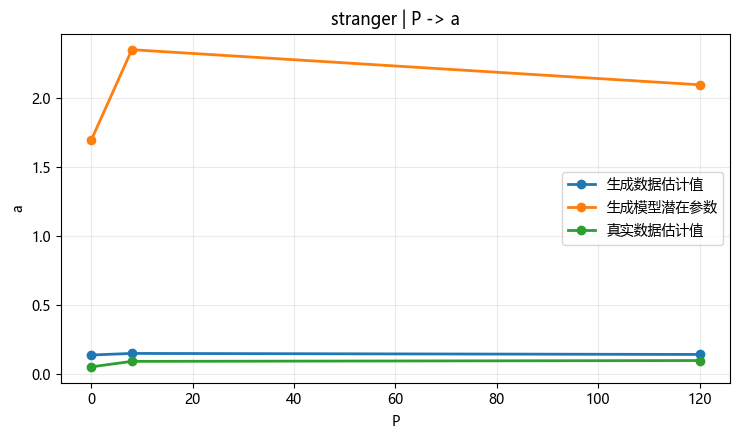

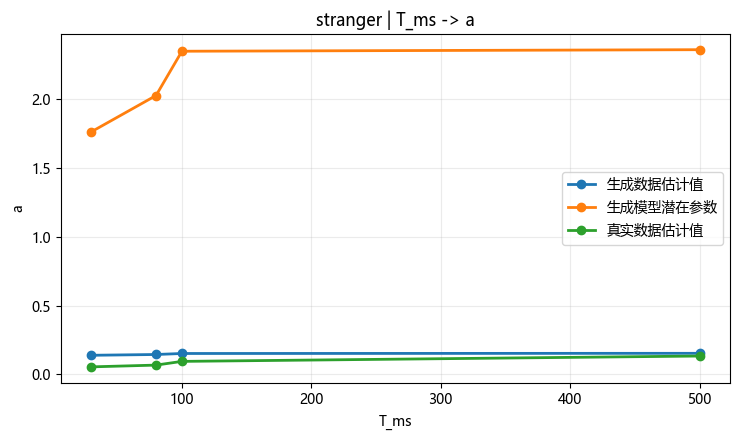

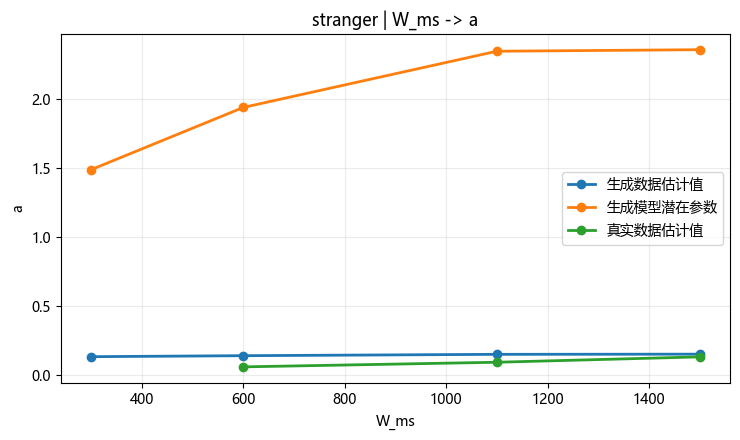

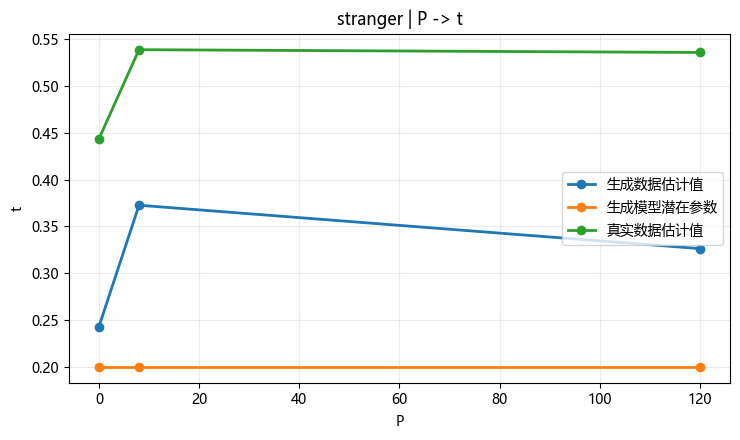

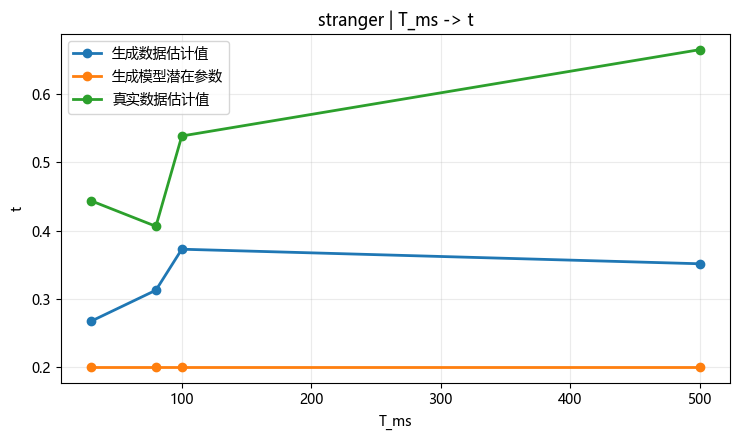

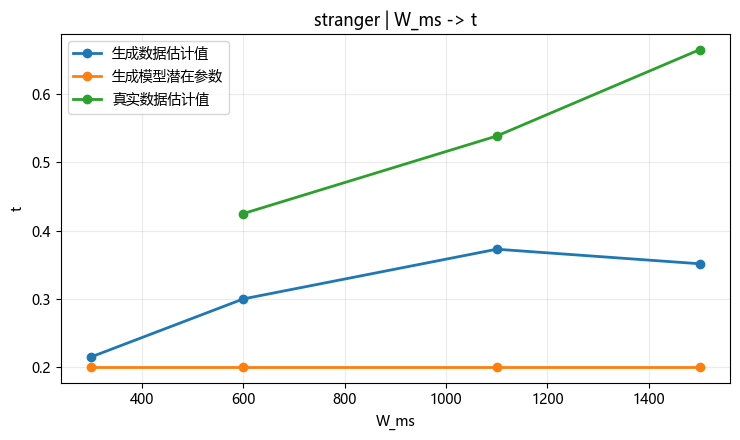

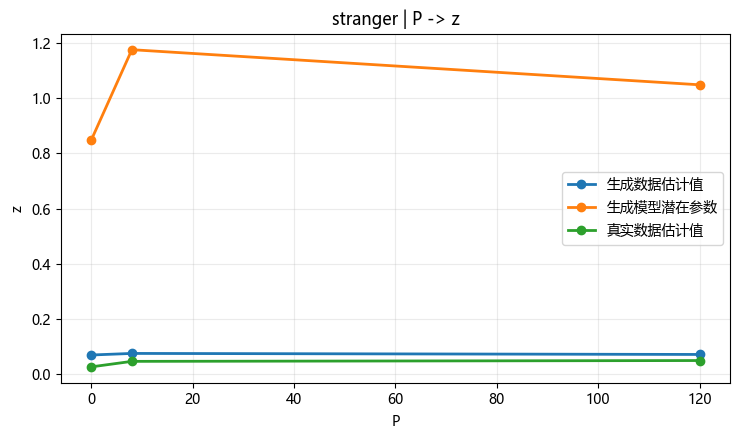

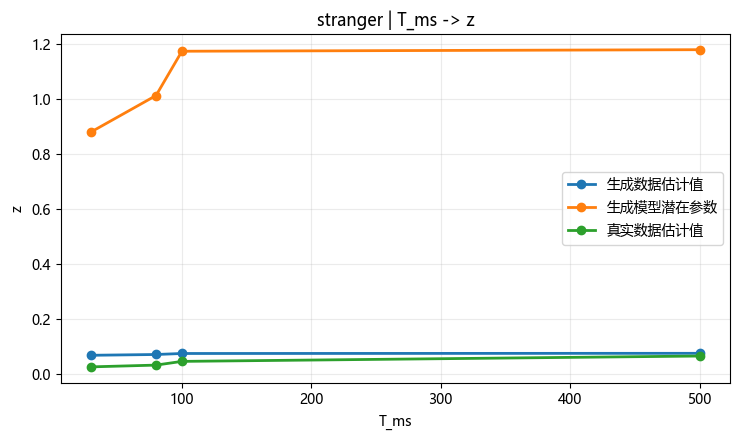

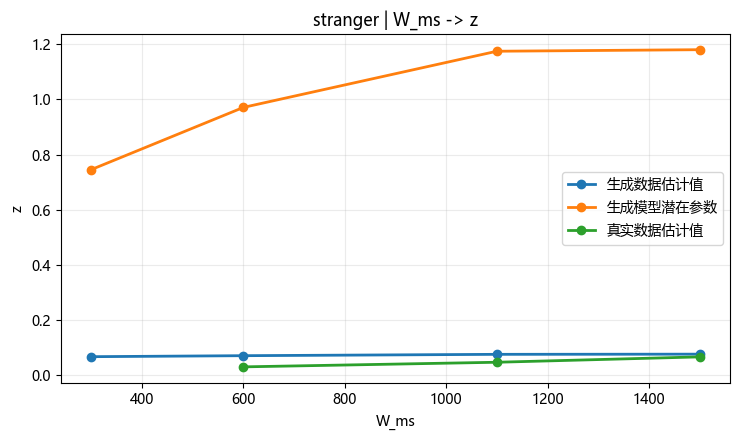

In [13]:
def plot_marginal_trends(df_long, label_value, param, x_var, save_name=None):
    sub = df_long[df_long['label'] == label_value].copy()
    summary = (
        sub.groupby([x_var, 'source'], as_index=False)[param]
           .mean()
           .sort_values([x_var, 'source'])
    )

    plt.figure(figsize=(7.5, 4.5))
    for source_name, part in summary.groupby('source'):
        plt.plot(part[x_var], part[param], marker='o', linewidth=2, label=source_name)
    plt.xlabel(x_var)
    plt.ylabel(param)
    plt.title(f'{label_value} | {x_var} -> {param}')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(compare_long['label'].dropna().unique()):
    for param in ['v', 'a', 't', 'z']:
        for x_var in ['P', 'T_ms', 'W_ms']:
            plot_marginal_trends(compare_long, label, param, x_var, save_name=f'{label}_{x_var}_{param}_marginal.png')

## 六、辅助比较：RT 与 ACC

虽然当前目标是比较 `v / a / t / z`，但把 `RT / ACC` 一起看一遍，有助于判断参数趋势差异是从哪里来的。

In [14]:
real_obs = (
    real.groupby(['condition_id', 'label'], as_index=False)
        .agg(
            P=('P', 'mean'),
            T_ms=('T_ms', 'mean'),
            W_ms=('W_ms', 'mean'),
            RT_real=('rt_s', 'mean'),
            ACC_real=('correct', 'mean'),
        )
)

gen_obs = (
    gen.groupby(['condition_id', 'label'], as_index=False)
       .agg(
           P=('P_target', 'mean'),
           T_ms=('T_ms_target', 'mean'),
           W_ms=('W_ms_target', 'mean'),
           RT_gen=('rt_s', 'mean'),
           ACC_gen=('correct', 'mean'),
       )
)

obs_compare = real_obs.merge(gen_obs, on=['condition_id', 'label', 'P', 'T_ms', 'W_ms'], how='outer').sort_values(['condition_id', 'label'])
obs_compare['condition_text'] = obs_compare.apply(lambda r: f"{r['condition_id']} | P={int(r['P'])}, T={int(r['T_ms'])}, W={int(r['W_ms'])}", axis=1)
display(obs_compare)

,condition_id,label,P,T_ms,W_ms,RT_real,ACC_real,RT_gen,ACC_gen,condition_text
0,C1,self,0.0,30.0,300.0,0.260549,0.125962,0.484365,0.885579,"C1 | P=0, T=30, W=300"
1,C1,stranger,0.0,30.0,300.0,0.258155,0.123077,0.638348,0.652246,"C1 | P=0, T=30, W=300"
2,C2,self,0.0,30.0,600.0,0.413090,0.282051,0.669182,0.854255,"C2 | P=0, T=30, W=600"
3,C2,stranger,0.0,30.0,600.0,0.406040,0.226068,0.792721,0.610993,"C2 | P=0, T=30, W=600"
4,C3,self,8.0,100.0,1100.0,0.697678,0.803297,0.743385,0.912500,"C3 | P=8, T=100, W=1100"
5,C3,stranger,8.0,100.0,1100.0,0.731930,0.705495,0.996097,0.616071,"C3 | P=8, T=100, W=1100"
6,C4,self,120.0,30.0,600.0,0.366229,0.343077,0.740293,0.777778,"C4 | P=120, T=30, W=600"
7,C4,stranger,120.0,30.0,600.0,0.360582,0.309615,0.805601,0.552490,"C4 | P=120, T=30, W=600"
8,C5,self,120.0,80.0,600.0,0.506318,0.511538,0.585923,0.947931,"C5 | P=120, T=80, W=600"
9,C5,stranger,120.0,80.0,600.0,0.505161,0.407143,0.846110,0.656560,"C5 | P=120, T=80, W=600"


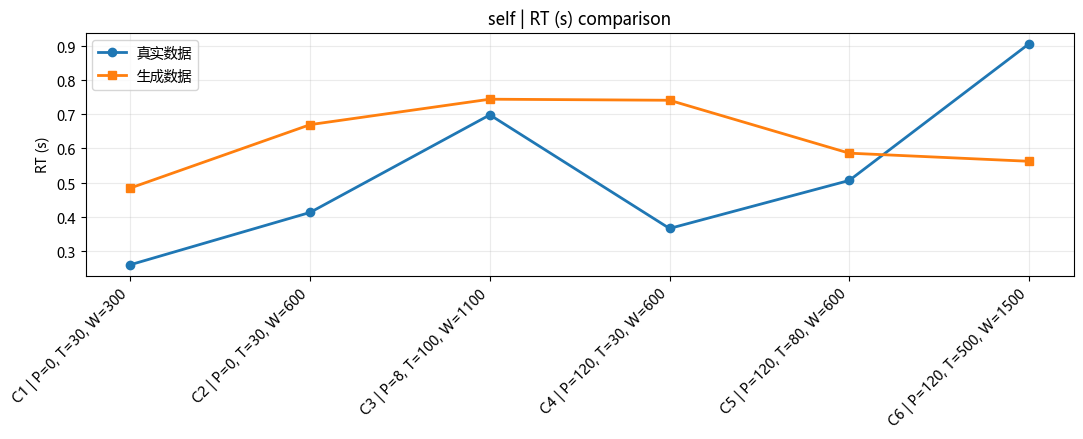

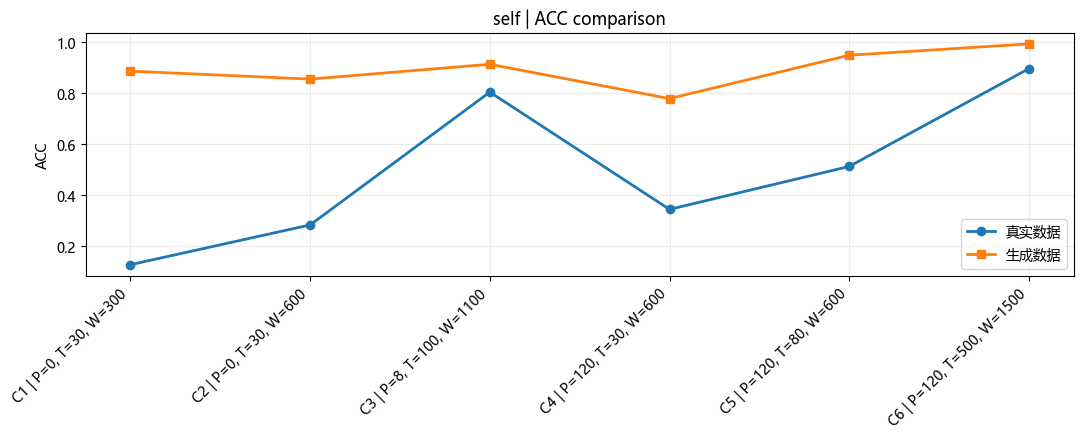

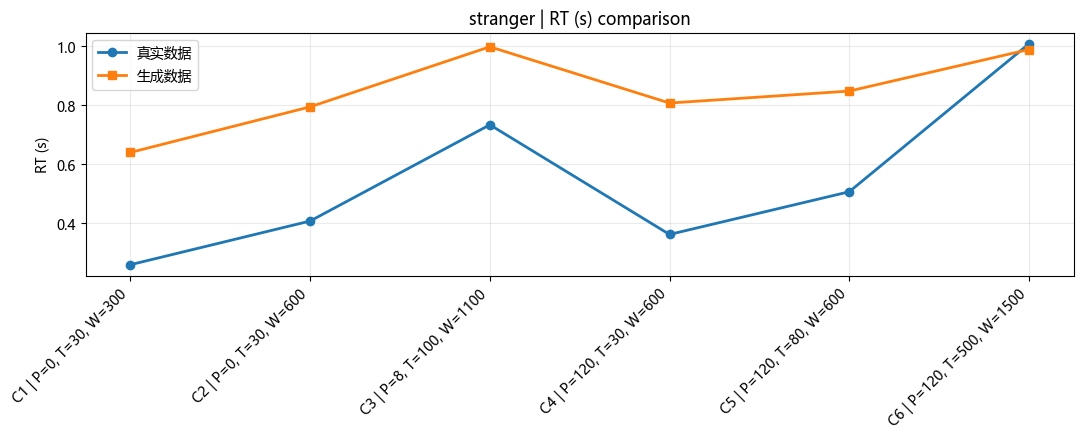

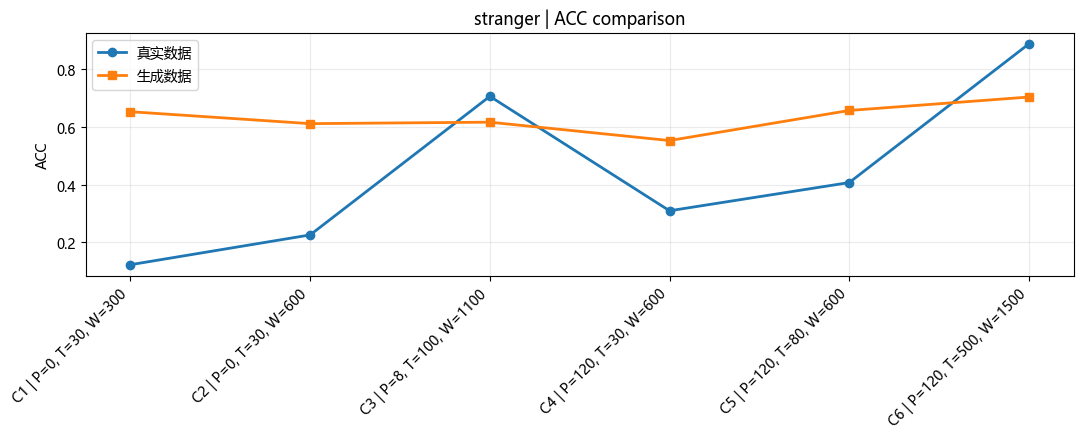

In [15]:
def plot_obs_compare(df, label_value, metric_real, metric_gen, ylabel, save_name=None):
    sub = df[df['label'] == label_value].sort_values(['P', 'T_ms', 'W_ms'])
    x = np.arange(len(sub))
    plt.figure(figsize=(11, 4.5))
    plt.plot(x, sub[metric_real], marker='o', linewidth=2, label='真实数据')
    plt.plot(x, sub[metric_gen], marker='s', linewidth=2, label='生成数据')
    plt.xticks(x, sub['condition_text'], rotation=45, ha='right')
    plt.ylabel(ylabel)
    plt.title(f'{label_value} | {ylabel} comparison')
    plt.legend()
    plt.grid(alpha=0.25)
    plt.tight_layout()
    if save_name is not None:
        plt.savefig(FIG_DIR / save_name, dpi=220, bbox_inches='tight')
    plt.show()

for label in sorted(obs_compare['label'].dropna().unique()):
    plot_obs_compare(obs_compare, label, 'RT_real', 'RT_gen', 'RT (s)', save_name=f'{label}_RT_compare.png')
    plot_obs_compare(obs_compare, label, 'ACC_real', 'ACC_gen', 'ACC', save_name=f'{label}_ACC_compare.png')

## 七、结论辅助表

最后输出一张方便写报告的表：

- 哪些参数在真实估计值与生成模型潜在参数之间趋势更一致
- 哪些参数在真实估计值与生成数据估计值之间一致性较弱

注意：这里的比较属于“趋势一致性检查”，不是正式参数恢复或层级 DDM 拟合。

In [16]:
summary_table = alignment_df.copy()
summary_table['better_match'] = np.where(
    summary_table['spearman_real_vs_gen_latent'] >= summary_table['spearman_real_vs_gen_est'],
    '生成模型潜在参数更接近真实趋势',
    '生成数据估计值更接近真实趋势'
)
display(summary_table)

summary_table.to_csv(FIG_DIR / 'trend_alignment_summary.csv', index=False)
compare_cond.to_csv(FIG_DIR / 'condition_level_param_compare.csv', index=False)
obs_compare.to_csv(FIG_DIR / 'condition_level_rt_acc_compare.csv', index=False)

print('已保存总结表到:', FIG_DIR)

,label,param,spearman_real_vs_gen_est,spearman_real_vs_gen_latent,better_match
0,self,v,0.4,0.4,生成模型潜在参数更接近真实趋势
1,self,a,0.8,1.0,生成模型潜在参数更接近真实趋势
2,self,t,0.8,NaN,生成数据估计值更接近真实趋势
3,self,z,0.8,1.0,生成模型潜在参数更接近真实趋势
4,stranger,v,0.8,1.0,生成模型潜在参数更接近真实趋势
5,stranger,a,0.8,1.0,生成模型潜在参数更接近真实趋势
6,stranger,t,0.6,NaN,生成数据估计值更接近真实趋势
7,stranger,z,0.8,1.0,生成模型潜在参数更接近真实趋势


已保存总结表到: d:\GitHub_programe\GitHub\Guassion-Process-Experiment-Design\3_Figures\Compare_Real_Generated_DDM_Params_v2.4.3
